# Contextual Data Fusion

Machine failures are rarely caused solely by internal machine conditions.

External environmental and operational factors can significantly influence failure probability.

This notebook enriches telemetry data with contextual variables and creates a unified dataset for predictive maintenance modeling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/telemetry_features.csv")

df.shape

(9991, 45)

## Simulating External Context

Because external APIs are unavailable for the historical AI4I dataset, realistic contextual variables are generated to mimic factory operating conditions.

In [3]:
np.random.seed(42)

In [4]:
df["ambient_humidity"] = np.random.normal(loc=60, scale=10, size=len(df))

df["ambient_humidity"] = df["ambient_humidity"].clip(30, 90)

In [5]:
df["energy_load_index"] = np.random.normal(70, 15, len(df))

df["energy_load_index"] = df["energy_load_index"].clip(20, 100)

In [6]:
df["production_demand"] = np.random.normal(75, 12, len(df))

df["production_demand"] = df["production_demand"].clip(30, 100)

In [7]:
df["days_since_maintenance"] = np.random.randint(1, 181, len(df))

In [8]:
df["shift"] = np.random.choice(["Day", "Night"], size=len(df))

In [9]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,Air temperature [K]_change,Process temperature [K]_change,Rotational speed [rpm]_change,Torque [Nm]_change,Tool wear [min]_change,ambient_humidity,energy_load_index,production_demand,days_since_maintenance,shift
0,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,...,0.2,0.3,74.0,-0.6,3.0,64.967142,72.871761,65.962661,2,Night
1,11,H29424,H,298.4,308.9,1782,23.9,24,0,0,...,-0.1,-0.1,41.0,-4.1,3.0,58.617357,79.932531,75.913229,69,Day
2,12,H29425,H,298.6,309.1,1423,44.3,29,0,0,...,0.2,0.2,-359.0,20.4,5.0,66.476885,47.520468,76.501596,13,Day
3,13,M14872,M,298.6,309.1,1339,51.1,34,0,0,...,0.0,0.0,-84.0,6.8,5.0,75.230299,87.913217,63.970096,147,Day
4,14,M14873,M,298.6,309.2,1742,30.0,37,0,0,...,0.0,0.1,403.0,-21.1,3.0,57.658466,89.516531,61.744500,83,Night


In [10]:
df["shift"] = df["shift"].map({"Day": 0, "Night": 1})

In [11]:
df.shape

(9991, 50)

## Context Variable Analysis

The following analysis investigates whether contextual variables show relationships with machine failures.

In [12]:
context_cols = [
    "ambient_humidity",
    "energy_load_index",
    "production_demand",
    "days_since_maintenance",
]

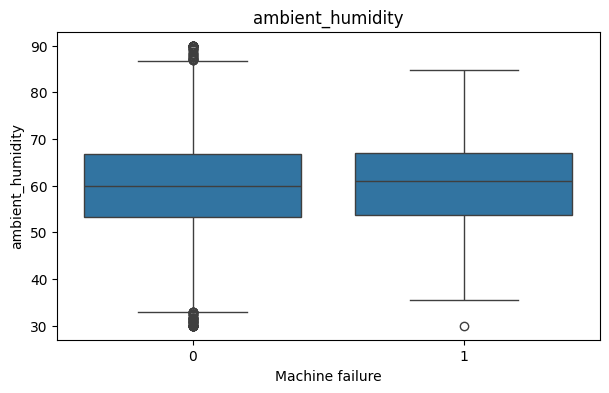

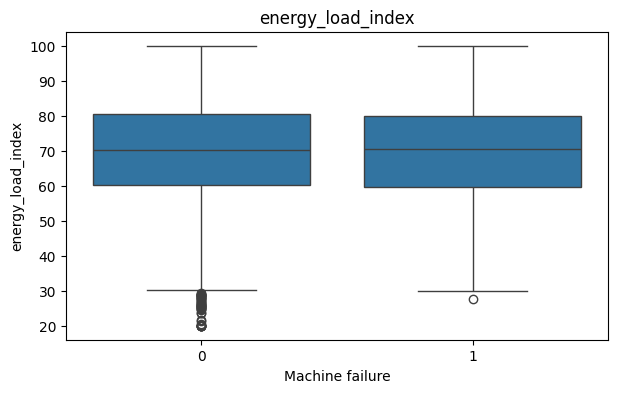

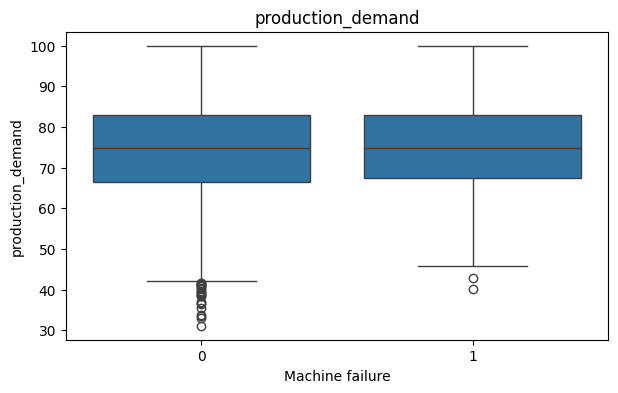

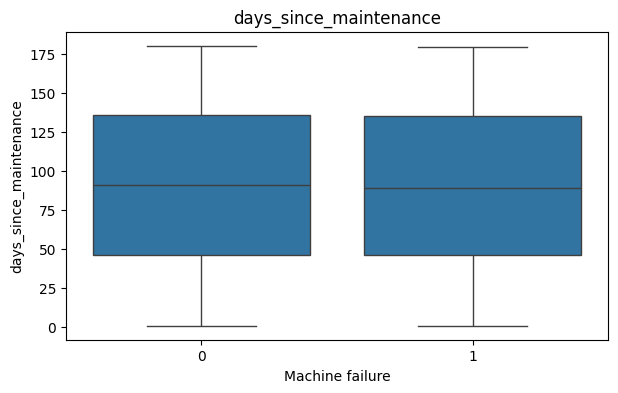

In [13]:
for col in context_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(data=df, x="Machine failure", y=col)

    plt.title(col)

    plt.show()

## Interaction Features

Interaction features capture combined effects between telemetry signals and contextual conditions.

In [14]:
df["torque_x_load"] = df["Torque [Nm]"] * df["energy_load_index"]

In [15]:
df["wear_x_demand"] = df["Tool wear [min]"] * df["production_demand"]

In [16]:
df["temp_x_humidity"] = df["Process temperature [K]"] * df["ambient_humidity"]

In [17]:
df.shape

(9991, 53)

In [18]:
df[
    [
        "ambient_humidity",
        "energy_load_index",
        "production_demand",
        "days_since_maintenance",
        "shift",
    ]
].head()

,ambient_humidity,energy_load_index,production_demand,days_since_maintenance,shift
0,64.967142,72.871761,65.962661,2,1
1,58.617357,79.932531,75.913229,69,0
2,66.476885,47.520468,76.501596,13,0
3,75.230299,87.913217,63.970096,147,0
4,57.658466,89.516531,61.744500,83,1


In [19]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,Torque [Nm]_change,Tool wear [min]_change,ambient_humidity,energy_load_index,production_demand,days_since_maintenance,shift,torque_x_load,wear_x_demand,temp_x_humidity
0,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,...,-0.6,3.0,64.967142,72.871761,65.962661,2,1,2040.409301,1385.215882,20074.846733
1,11,H29424,H,298.4,308.9,1782,23.9,24,0,0,...,-4.1,3.0,58.617357,79.932531,75.913229,69,0,1910.387498,1821.917496,18106.901574
2,12,H29425,H,298.6,309.1,1423,44.3,29,0,0,...,20.4,5.0,66.476885,47.520468,76.501596,13,0,2105.156712,2218.546281,20548.005271
3,13,M14872,M,298.6,309.1,1339,51.1,34,0,0,...,6.8,5.0,75.230299,87.913217,63.970096,147,0,4492.365401,2174.983267,23253.685286
4,14,M14873,M,298.6,309.2,1742,30.0,37,0,0,...,-21.1,3.0,57.658466,89.516531,61.744500,83,1,2685.495928,2284.546512,17827.997765


## Saving Context-Enriched Dataset

The fused dataset combines machine telemetry and contextual information and serves as the foundation for predictive maintenance modeling.

In [20]:
import re

df.columns = [re.sub(r"[^A-Za-z0-9_]", "_", col) for col in df.columns]

In [21]:
df.to_csv("../data/processed/context_fused_dataset.csv", index=False)

print("Saved successfully.")

Saved successfully.


In [22]:
df.columns

Index(['UDI', 'Product_ID', 'Type', 'Air_temperature__K_',
       'Process_temperature__K_', 'Rotational_speed__rpm_', 'Torque__Nm_',
       'Tool_wear__min_', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Air_temperature__K__roll_mean', 'Process_temperature__K__roll_mean',
       'Rotational_speed__rpm__roll_mean', 'Torque__Nm__roll_mean',
       'Tool_wear__min__roll_mean', 'Air_temperature__K__roll_std',
       'Process_temperature__K__roll_std', 'Rotational_speed__rpm__roll_std',
       'Torque__Nm__roll_std', 'Tool_wear__min__roll_std',
       'Air_temperature__K__roll_var', 'Process_temperature__K__roll_var',
       'Rotational_speed__rpm__roll_var', 'Torque__Nm__roll_var',
       'Tool_wear__min__roll_var', 'Air_temperature__K__lag1',
       'Air_temperature__K__lag2', 'Process_temperature__K__lag1',
       'Process_temperature__K__lag2', 'Rotational_speed__rpm__lag1',
       'Rotational_speed__rpm__lag2', 'Torque__Nm__lag1', 'Torque__Nm__lag2',
       'Tool_wear

In [23]:
df.shape

(9991, 53)

## Conclusion

Telemetry features were enriched using rolling statistics, lag features, trend features, contextual variables, and interaction terms. The validated contextual dataset is now ready for predictive modeling.